# Branch & Bound — Interactive Notebook

> Step through an ILP/MIP B&B search tree node by node.
> Pick a problem, choose a strategy, export a standalone HTML viewer.

---
**Quick start:** edit **§2** (uncomment one problem), run **§3** (optional random generator),
then `Cell → Run All` — the HTML viewer is produced automatically in **§4**.
---

## 1 · Imports

In [9]:
# First run only — uncomment to install:
# !pip install pulp ipywidgets matplotlib pandas -q

import math, copy, random, json as _json, base64 as _b64
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional, List

import pulp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
from IPython.display import display, HTML

matplotlib.rcParams.update({
    "figure.facecolor": "#080c12",
    "axes.facecolor":   "#080c12",
    "text.color":       "#b0c4d8",
    "axes.labelcolor":  "#b0c4d8",
    "xtick.color":      "#4a6580",
    "ytick.color":      "#4a6580",
})
print("OK — libraries loaded")

OK — libraries loaded


## 2 · Problem Selection

**Uncomment exactly one block** and run the cell.
The variable `PROBLEM` is used by every cell below.

In [10]:
# ┌─────────────────────────────────────────────────────────────────┐
# │  Uncomment ONE block below, keep all others commented.          │
# └─────────────────────────────────────────────────────────────────┘

# ── PRESET A  Classic 2-variable IP ──────────────────────────────────────────
# PROBLEM = {
#     "name": "Classic 2-variable IP",
#     "display": "max  5x1 + 4x2",
#     "var_names": ["x1", "x2"],
#     "objective": {"x1": 5, "x2": 4},
#     "sense": "max",
#     "constraints": [
#         {"coeffs": {"x1": 6, "x2": 4}, "sense": "<=", "rhs": 24, "name": "6x1+4x2<=24"},
#         {"coeffs": {"x1": 1, "x2": 2}, "sense": "<=", "rhs": 6,  "name": "x1+2x2<=6"},
#     ],
#     "integer_vars": ["x1", "x2"],
# }

# ── PRESET B  3-variable MIP (x3 continuous) ─────────────────────────────────
PROBLEM = {
    "name": "3-variable MIP (x3 continuous)",
    "display": "max  3x1 + 5x2 + 2x3",
    "var_names": ["x1", "x2", "x3"],
    "objective": {"x1": 3, "x2": 5, "x3": 2},
    "sense": "max",
    "constraints": [
        {"coeffs": {"x1": 2, "x2": 4, "x3": 1}, "sense": "<=", "rhs": 14, "name": "2x1+4x2+x3<=14"},
        {"coeffs": {"x1": 1, "x2": 3, "x3": 2}, "sense": "<=", "rhs": 10, "name": "x1+3x2+2x3<=10"},
        {"coeffs": {"x1": 1, "x2": 0, "x3": 1}, "sense": "<=", "rhs":  4, "name": "x1+x3<=4"},
    ],
    "integer_vars": ["x1", "x2"],   # x3 stays continuous → MIP
}

# ── PRESET C  Capital Budgeting 0-1 IP ───────────────────────────────────────
# PROBLEM = {
#     "name": "Capital Budgeting (0-1 IP)",
#     "display": "max  8x1 + 5x2 + 10x3 + 7x4",
#     "var_names": ["x1", "x2", "x3", "x4"],
#     "objective": {"x1": 8, "x2": 5, "x3": 10, "x4": 7},
#     "sense": "max",
#     "constraints": [
#         {"coeffs": {"x1": 5, "x2": 3, "x3": 8, "x4": 6}, "sense": "<=", "rhs": 12,
#          "name": "5x1+3x2+8x3+6x4<=12"},
#     ],
#     "integer_vars": ["x1", "x2", "x3", "x4"],
#     "var_bounds":   {"x1": (0,1), "x2": (0,1), "x3": (0,1), "x4": (0,1)},
# }

# ── PRESET D  Tight 5-variable IP ────────────────────────────────────────────
# PROBLEM = {
#     "name": "Tight 5-variable IP",
#     "display": "max  10x1 + 6x2 + 4x3 + 7x4 + 5x5",
#     "var_names": ["x1", "x2", "x3", "x4", "x5"],
#     "objective": {"x1": 10, "x2": 6, "x3": 4, "x4": 7, "x5": 5},
#     "sense": "max",
#     "constraints": [
#         {"coeffs": {"x1":6,"x2":3,"x3":2,"x4":5,"x5":2}, "sense":"<=", "rhs":15,
#          "name":"6x1+3x2+2x3+5x4+2x5<=15"},
#         {"coeffs": {"x1":1,"x2":4,"x3":3,"x4":2,"x5":4}, "sense":"<=", "rhs":12,
#          "name":"x1+4x2+3x3+2x4+4x5<=12"},
#     ],
#     "integer_vars": ["x1", "x2", "x3", "x4", "x5"],
# }

# ── PRESET E  Random Knapsack (generated in §3) ───────────────────────────────
# PROBLEM = _generated   # <- run §3 first, then uncomment this line

# ─────────────────────────────────────────────────────────────────────────────
# Print a quick summary so you know what's active
_iv = PROBLEM.get("integer_vars", [])
_cs = PROBLEM.get("constraints", [])
print(f"  Problem : {PROBLEM['name']}")
print(f"  {PROBLEM['display']}")
print(f"  Variables ({len(PROBLEM['var_names'])}): {', '.join(PROBLEM['var_names'])}")
print(f"  Integer  ({len(_iv)}): {', '.join(_iv) if _iv else 'none (pure LP)'}")
print(f"  Constraints: {len(_cs)}")
for c in _cs:
    print(f"    {c['name']}")

  Problem : 3-variable MIP (x3 continuous)
  max  3x1 + 5x2 + 2x3
  Variables (3): x1, x2, x3
  Integer  (2): x1, x2
  Constraints: 3
    2x1+4x2+x3<=14
    x1+3x2+2x3<=10
    x1+x3<=4


## 3 · Random Knapsack Generator  *(optional)*

Edit the parameters, run the cell — `_generated` is set.
Then go back to **§2**, comment all blocks and uncomment **PRESET E**.

In [11]:
# ══════════════════════════════════════════════
#   PARAMETERS — edit these freely
# ══════════════════════════════════════════════

N_VARS      = 10        # number of items / variables  (try 5, 8, 10, 12, 15)
SEED        = 42       # random seed — change for a different instance
BINARY      = True     # True  → 0-1 knapsack  (x_j ∈ {0,1})
                       # False → bounded knapsack  (x_j ∈ {0, 3})
CAP_RATIO   = 0.40     # W / Σ weights  — lower = tighter = bigger tree
                       # try 0.20 (very tight), 0.40 (moderate), 0.65 (loose)
N_CONSTRAINTS = 1      # extra knapsack constraints (1 = classic, 2-3 = richer MIP)

# ══════════════════════════════════════════════
#   Generator  — don't need to edit below here
# ══════════════════════════════════════════════

def _make_knapsack(n, cap_ratio, seed, binary, n_constraints):
    rng     = random.Random(seed)
    values  = [rng.randint(5, 25) for _ in range(n)]
    vnames  = ["x" + str(i+1) for i in range(n)]
    ub      = 1 if binary else 3

    constraints = []
    for ci in range(n_constraints):
        weights = [rng.randint(2, 12) for _ in range(n)]
        W       = max(1, int(cap_ratio * sum(weights)))
        lhs     = " + ".join(f"{w}{v}" for w, v in zip(weights, vnames))
        constraints.append({
            "coeffs": {v: w for v, w in zip(vnames, weights)},
            "sense": "<=",
            "rhs":   W,
            "name":  f"{lhs} <= {W}",
        })

    obj_str = " + ".join(f"{v}{vn}" for v, vn in zip(values, vnames))
    return {
        "name": (f"{'0-1' if binary else 'Bounded'} Knapsack  "
                 f"n={n}  seed={seed}  caps={[c['rhs'] for c in constraints]}"),
        "display": f"max  {obj_str}",
        "var_names": vnames,
        "objective": {v: val for v, val in zip(vnames, values)},
        "sense": "max",
        "constraints": constraints,
        "integer_vars": vnames,
        "var_bounds":   {v: (0, ub) for v in vnames},
        "_meta": {
            "values": values, "n": n, "seed": seed,
            "binary": binary, "cap_ratio": cap_ratio,
        },
    }

_generated = _make_knapsack(N_VARS, CAP_RATIO, SEED, BINARY, N_CONSTRAINTS)

# Pretty-print the instance
meta  = _generated["_meta"]
print(f"  Generated : {_generated['name']}")
print(f"  Objective : {_generated['display']}")
print(f"  Variables : {', '.join(_generated['var_names'])}")
print(f"  Values    : {meta['values']}")
for c in _generated["constraints"]:
    print(f"  Constraint: {c['name']}")
print()
print("  ✓ _generated is ready.")
print("  → Go to §2, comment all blocks, uncomment  PROBLEM = _generated")
PROBLEM = _generated

  Generated : 0-1 Knapsack  n=10  seed=42  caps=[23]
  Objective : max  25x1 + 8x2 + 5x3 + 13x4 + 12x5 + 12x6 + 9x7 + 8x8 + 22x9 + 7x10
  Variables : x1, x2, x3, x4, x5, x6, x7, x8, x9, x10
  Values    : [25, 8, 5, 13, 12, 12, 9, 8, 22, 7]
  Constraint: 11x1 + 8x2 + 2x3 + 2x4 + 3x5 + 5x6 + 5x7 + 10x8 + 11x9 + 2x10 <= 23

  ✓ _generated is ready.
  → Go to §2, comment all blocks, uncomment  PROBLEM = _generated


## 4 · B&B Engine

Data structures, LP solver (PuLP/CBC), and the B&B loop with
**DFS**, **Best-First**, and **Breadth-First** strategies.
No need to edit this cell.

In [12]:
EPS = 1e-6

@dataclass
class NodeResult:
    status: str
    lp_val: Optional[float]
    lp_sol: dict
    is_integer: bool
    frac_vars: list   # [(var, value)] sorted most-fractional first

@dataclass
class BnBNode:
    id:           int
    parent_id:    Optional[int]
    depth:        int
    lb:           dict
    ub:           dict
    branch_desc:  str  = ""
    status:       str  = "open"
    lp_val:       Optional[float] = None
    lp_sol:       dict = field(default_factory=dict)
    frac_vars:    list = field(default_factory=list)
    prune_reason: str  = ""
    children:     list = field(default_factory=list)

@dataclass
class Frame:
    step:       int
    event:      str
    current_id: Optional[int]
    nodes:      dict
    queue:      list
    best_val:   Optional[float]
    best_sol:   dict
    info:       dict


def solve_lp(problem: dict, node: BnBNode) -> NodeResult:
    vnames = problem["var_names"]
    iv     = set(problem.get("integer_vars", []))
    db     = problem.get("var_bounds", {})

    lp = pulp.LpProblem(
        "n", pulp.LpMaximize if problem["sense"] == "max" else pulp.LpMinimize
    )
    vars_ = {}
    for v in vnames:
        lo, hi = db.get(v, (0, None))
        lo      = max(lo, node.lb.get(v, lo))
        hi_nd   = node.ub.get(v, hi)
        hi      = hi_nd if hi is None else (min(hi, hi_nd) if hi_nd is not None else hi)
        if v in iv:
            lo = math.ceil(lo - EPS)
            if hi is not None:
                hi = math.floor(hi + EPS)
        vars_[v] = pulp.LpVariable(v, lowBound=lo, upBound=hi, cat="Continuous")

    lp += pulp.lpSum(problem["objective"].get(v, 0) * vars_[v] for v in vnames)
    for i, c in enumerate(problem["constraints"]):
        expr = pulp.lpSum(c["coeffs"].get(v, 0) * vars_[v] for v in vnames)
        if   c["sense"] == "<=": lp += expr <= c["rhs"], "c" + str(i)
        elif c["sense"] == ">=": lp += expr >= c["rhs"], "c" + str(i)
        else:                     lp += expr == c["rhs"], "c" + str(i)

    lp.solve(pulp.PULP_CBC_CMD(msg=0))
    smap = {1:"optimal", 0:"infeasible", -1:"infeasible", -2:"unbounded", -3:"infeasible"}
    st   = smap.get(lp.status, "infeasible")
    if st != "optimal":
        return NodeResult(status=st, lp_val=None, lp_sol={},
                          is_integer=False, frac_vars=[])

    sol    = {v: round(pulp.value(vars_[v]) or 0, 8) for v in vnames}
    lp_val = round(pulp.value(lp.objective), 8)
    frac   = [(v, sol[v]) for v in iv if abs(sol[v] - round(sol[v])) > EPS]
    frac.sort(key=lambda p: -min(p[1] - math.floor(p[1]), math.ceil(p[1]) - p[1]))
    return NodeResult(status="optimal", lp_val=lp_val, lp_sol=sol,
                      is_integer=len(frac) == 0, frac_vars=frac)


def run_bnb(problem: dict, strategy: str = "dfs") -> List[Frame]:
    '''
    strategy: "dfs"   LIFO - children prepended (fast incumbent)
              "best"  pop highest LP bound (fewest nodes)
              "bfs"   FIFO - children appended (level-by-level)
    '''
    vb     = problem.get("var_bounds", {v: (0, None) for v in problem["var_names"]})
    nodes  = {}
    ctr    = [0]
    queue  = []
    bv     = [None]
    bs     = [{}]
    frames = []
    step   = [0]

    def new_node(pid, depth, lb, ub, bd=""):
        ctr[0] += 1
        nid = ctr[0]
        nodes[nid] = BnBNode(id=nid, parent_id=pid, depth=depth,
                             lb=copy.deepcopy(lb), ub=copy.deepcopy(ub),
                             branch_desc=bd)
        return nid

    def snap(ev, cur, info=None):
        frames.append(Frame(
            step=step[0], event=ev, current_id=cur,
            nodes=copy.deepcopy(nodes), queue=list(queue),
            best_val=bv[0], best_sol=dict(bs[0]), info=info or {},
        ))

    lb0 = {v: vb.get(v, (0, None))[0] for v in problem["var_names"]}
    ub0 = {v: vb.get(v, (0, None))[1] for v in problem["var_names"]}
    root_id = new_node(None, 0, lb0, ub0)
    queue   = [root_id]
    snap("start", root_id, {"strategy": strategy})

    def evaluate_node(nid):
        nd      = nodes[nid]
        step[0] += 1
        result  = solve_lp(problem, nd)
        nd.lp_val    = result.lp_val
        nd.lp_sol    = result.lp_sol
        nd.frac_vars = result.frac_vars

        if result.status == "infeasible":
            nd.status = "pruned_inf"
            snap("prune_inf", nid, {"reason": "infeasible"})
            return False

        nd.status = "lp_solved"
        snap("lp_solved", nid, {
            "lp_val": result.lp_val,
            "lp_sol": result.lp_sol,
            "frac_vars": result.frac_vars,
        })

        if bv[0] is not None and result.lp_val <= bv[0] + EPS:
            nd.status = "pruned_bound"
            snap("prune_bound", nid, {"lp_val": result.lp_val, "best_val": bv[0]})
            return False

        if result.is_integer:
            nd.status = "integer"
            step[0]  += 1
            is_new = bv[0] is None or result.lp_val > bv[0] + EPS
            if is_new:
                bv[0] = round(result.lp_val, 8)
                bs[0] = {v: round(result.lp_sol[v]) for v in problem["var_names"]}
            snap("integer", nid, {
                "lp_val": result.lp_val,
                "lp_sol": result.lp_sol,
                "is_new_best": is_new,
            })
            return False

        return True

    while queue:
        if strategy == "best":
            for qid in list(queue):
                qn = nodes[qid]
                if qn.status == "open" and qn.lp_val is None:
                    if not evaluate_node(qid):
                        queue.remove(qid)
                        continue
                if bv[0] is not None and qn.lp_val is not None and qn.lp_val <= bv[0] + EPS:
                    qn.status = "pruned_bound"
                    step[0]  += 1
                    snap("prune_bound", qid, {"lp_val": qn.lp_val, "best_val": bv[0]})
                    queue.remove(qid)

            if not queue:
                continue

            bi = max(range(len(queue)), key=lambda i: nodes[queue[i]].lp_val)
            nid = queue.pop(bi)
            nd  = nodes[nid]
        else:
            nid = queue.pop(0)
            if not evaluate_node(nid):
                continue
            nd = nodes[nid]

        bvar, bval = nd.frac_vars[0]
        lo_b, hi_b = math.floor(bval), math.ceil(bval)

        lb_l = copy.deepcopy(nd.lb); ub_l = copy.deepcopy(nd.ub)
        ch = ub_l.get(bvar)
        ub_l[bvar] = lo_b if ch is None else min(lo_b, ch)
        left_id = new_node(nid, nd.depth + 1, lb_l, ub_l, bvar + "<=" + str(lo_b))

        lb_r = copy.deepcopy(nd.lb); ub_r = copy.deepcopy(nd.ub)
        lb_r[bvar] = max(hi_b, lb_r.get(bvar, 0))
        right_id = new_node(nid, nd.depth + 1, lb_r, ub_r, bvar + ">=" + str(hi_b))

        nd.status   = "branched"
        nd.children = [left_id, right_id]
        queue = ([left_id, right_id] + queue if strategy == "dfs"
                 else queue + [left_id, right_id])

        step[0] += 1
        snap("branch", nid, {
            "bvar": bvar, "bval": bval,
            "lo": lo_b, "hi": hi_b,
            "left_id": left_id, "right_id": right_id,
        })

    step[0] += 1
    snap("done", None, {
        "best_val": bv[0], "best_sol": bs[0],
        "total_nodes": len(nodes), "strategy": strategy,
    })
    return frames


print("Engine ready")

Engine ready


## 5 · Solve

```
STRATEGY = "dfs"    # depth-first  — LIFO, fast incumbent, low memory
STRATEGY = "best"   # best-first   — fewest nodes explored
STRATEGY = "bfs"    # breadth-first — level by level
```

Edit `STRATEGY` and run the cell.

In [13]:
# ══════════════════════════════════════════════
#   Choose ONE strategy
# ══════════════════════════════════════════════

# STRATEGY = "dfs"      # depth-first  (LIFO)
STRATEGY = "best"   # best-first   (highest LP bound)
# STRATEGY = "bfs"    # breadth-first (FIFO)

# ══════════════════════════════════════════════
FRAMES: List[Frame] = run_bnb(PROBLEM, strategy=STRATEGY)

_pruned   = sum(1 for f in FRAMES if f.event in ("prune_inf", "prune_bound"))
_integers = sum(1 for f in FRAMES if f.event == "integer")
_opt      = FRAMES[-1].best_val
_sol      = FRAMES[-1].best_sol
_sol_str  = "  ".join(f"{k}={v}" for k, v in _sol.items()) if _sol else "—"

print(f"  Strategy : {STRATEGY.upper()}")
print(f"  Frames   : {len(FRAMES)}")
print(f"  Nodes    : {len(FRAMES[-1].nodes)}")
print(f"  Pruned   : {_pruned}")
print(f"  Integer solutions found: {_integers}")
print(f"  Optimal z* = {_opt}    {_sol_str}")

  Strategy : BEST
  Frames   : 16
  Nodes    : 7
  Pruned   : 3
  Integer solutions found: 1
  Optimal z* = 69.0    x1=1  x2=0  x3=0  x4=1  x5=1  x6=1  x7=0  x8=0  x9=0  x10=1


## 6 · Generate Interactive HTML Viewer

Bakes all frames into a **single self-contained HTML file**.
Open `bnb_trace.html` in any browser — no server, no Python needed.

Controls: **◀ / ▶** buttons · slider · **Space / ← →** keys · **▶ Play**

In [14]:
def _serialise(frames: List[Frame], problem: dict) -> dict:
    def _nd(n):
        return {
            "id": n.id, "parent_id": n.parent_id, "depth": n.depth,
            "branch_desc": n.branch_desc, "status": n.status,
            "lp_val": n.lp_val, "lp_sol": n.lp_sol,
            "frac_vars": n.frac_vars, "prune_reason": n.prune_reason,
            "children": n.children,
        }
    return {
        "problem": {
            "name":         problem["name"],
            "display":      problem["display"],
            "var_names":    problem["var_names"],
            "objective":    problem["objective"],
            "sense":        problem["sense"],
            "constraints":  problem["constraints"],
            "integer_vars": problem.get("integer_vars", []),
            "var_bounds": {
                k: list(v) for k, v in
                problem.get("var_bounds",
                            {v: (0, None) for v in problem["var_names"]}).items()
            },
        },
        "strategy": frames[-1].info.get("strategy", "dfs") if frames else "dfs",
        "frames": [
            {
                "step": f.step, "event": f.event, "current_id": f.current_id,
                "nodes": {str(k): _nd(v) for k, v in f.nodes.items()},
                "queue": f.queue, "best_val": f.best_val,
                "best_sol": f.best_sol, "info": f.info,
            }
            for f in frames
        ],
    }


# Load template (must be in the same folder as the notebook)
import os as _os
_tpl_path = Path(_os.path.dirname(_os.path.abspath("__file__"))) / "viewer_template.html"
if not _tpl_path.exists():
    _tpl_path = Path("viewer_template.html")

_tpl   = _tpl_path.read_text(encoding="utf-8")
_trace = _serialise(FRAMES, PROBLEM)
_html  = _tpl.replace("__TRACE__", _json.dumps(_trace, ensure_ascii=False))

_out = Path("bnb_trace.html")
_out.write_text(_html, encoding="utf-8")
_b64str = _b64.b64encode(_html.encode()).decode()

display(HTML(
    '<div style="font-family:\'IBM Plex Mono\',monospace;background:#062a1a;'
    'padding:12px 18px;border-radius:6px;border:1px solid #00c4a040;font-size:.82em">'
    '<b style="color:#00c4a0">&#10003; HTML viewer ready!</b><br>'
    '<span style="color:#4a7090">File:</span> '
    '<code style="color:#38aadc">bnb_trace.html</code>'
    f' ({round(len(_html)/1024,1)} kB)&nbsp;&nbsp;'
    f'<span style="color:#4a7090">Frames:</span> '
    f'<span style="color:#b0c4d8">{len(FRAMES)}</span>&nbsp;&nbsp;'
    f'<span style="color:#4a7090">Nodes:</span> '
    f'<span style="color:#b0c4d8">{len(FRAMES[-1].nodes)}</span>&nbsp;&nbsp;'
    f'<b style="color:#00c4a0">z* = {FRAMES[-1].best_val}</b><br><br>'
    '<a href="data:text/html;base64,' + _b64str + '" download="bnb_trace.html" '
    'style="color:#e8a020;font-weight:600;text-decoration:none;'
    'border:1px solid #e8a020;padding:4px 14px;border-radius:3px;display:inline-block">'
    '&#8595; Download bnb_trace.html</a>'
    '&nbsp;&nbsp;<span style="color:#4a7090;font-size:.9em">'
    'or open the file from disk</span>'
    '</div>'
))

# Inline preview
display(HTML(
    '<iframe src="data:text/html;base64,' + _b64str + '" '
    'width="100%" height="620px" '
    'style="border:1px solid #1e3248;border-radius:6px;margin-top:8px">'
    '</iframe>'
))

/Users/seman/DAS410049/bnb/.venv/lib/python3.13/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## 7 · Strategy Comparison Chart

Runs **DFS, Best-First, BFS** on the current problem and plots:
- **Left** — LP upper bound and incumbent converging over frames
- **Right** — node count breakdown per strategy

Re-run after changing the problem.

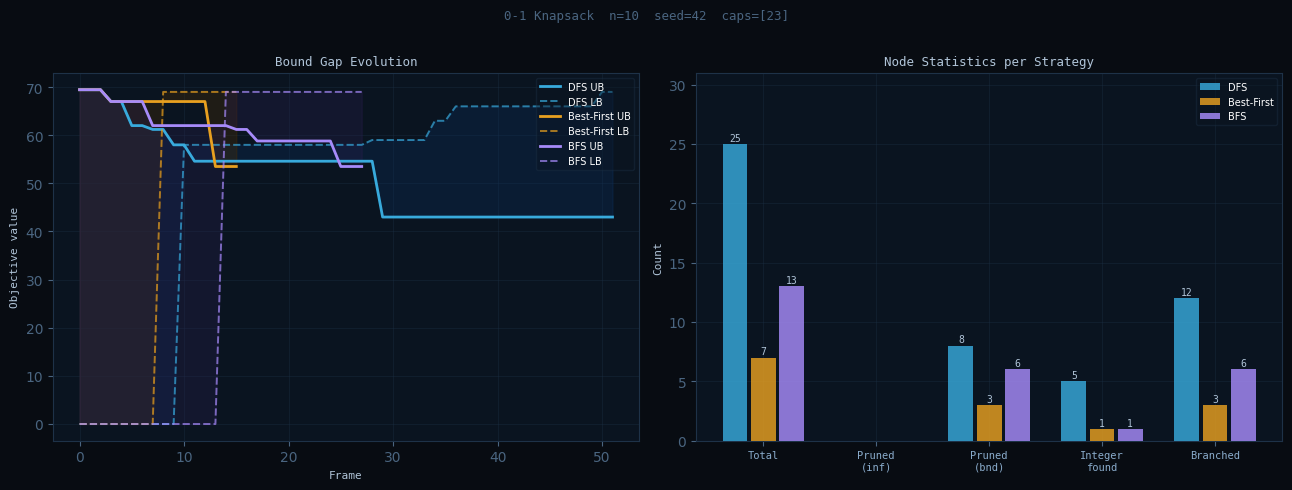

In [15]:
def _ub_lb(frames):
    ub, lb_ = [], []
    ru, rl  = None, None
    for f in frames:
        if f.event == "lp_solved" and f.info.get("lp_val") is not None:
            cand = f.info["lp_val"]
            ru   = cand if ru is None else min(ru, cand)
        if f.best_val is not None:
            rl = f.best_val
        ub.append(ru); lb_.append(rl)
    fu = next((v for v in ub if v is not None), 0)
    return ([v if v is not None else fu for v in ub],
            [v if v is not None else 0  for v in lb_])


def plot_strategy_comparison(problem: dict):
    strats = {"DFS": "dfs", "Best-First": "best", "BFS": "bfs"}
    all_f  = {k: run_bnb(problem, strategy=v) for k, v in strats.items()}
    COLS   = {
        "DFS":        ("#38aadc", "#0c3060"),
        "Best-First": ("#e8a020", "#503000"),
        "BFS":        ("#a78bfa", "#2a1e50"),
    }

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    fig.patch.set_facecolor("#080c12")
    for ax in axes:
        ax.set_facecolor("#0a1420")
        for sp in ax.spines.values(): sp.set_edgecolor("#1e3248")
        ax.tick_params(colors="#4a6580")
        ax.grid(True, color="#1e3248", lw=0.5, alpha=0.5)

    # ── Left: bound gap ──────────────────────────────────────────────
    ax = axes[0]
    ax.set_title("Bound Gap Evolution",
                 color="#b0c4d8", fontfamily="monospace", fontsize=9, pad=6)
    ax.set_xlabel("Frame", fontsize=8, fontfamily="monospace")
    ax.set_ylabel("Objective value", fontsize=8, fontfamily="monospace")
    for label, frames in all_f.items():
        lc, sc = COLS[label]
        ub, lb_ = _ub_lb(frames)
        xs = list(range(len(frames)))
        ax.plot(xs, ub,  color=lc, lw=2.0, label=label + " UB", zorder=4)
        ax.plot(xs, lb_, color=lc, lw=1.4, ls="--", alpha=0.7,
                label=label + " LB", zorder=4)
        ax.fill_between(xs, lb_, ub, color=sc, alpha=0.30, zorder=2)
    ax.legend(fontsize=7, framealpha=0.4, facecolor="#0a1420",
              edgecolor="#1e3248", labelcolor="white", loc="upper right")

    # ── Right: node stats ────────────────────────────────────────────
    ax2 = axes[1]
    ax2.set_title("Node Statistics per Strategy",
                  color="#b0c4d8", fontfamily="monospace", fontsize=9, pad=6)
    ax2.set_ylabel("Count", fontsize=8, fontfamily="monospace")
    cats = ["Total", "Pruned\n(inf)", "Pruned\n(bnd)", "Integer\nfound", "Branched"]
    x    = np.arange(len(cats))
    w    = 0.25
    offs = [-w, 0, w]
    for (label, frames), offset, col in zip(all_f.items(), offs,
                                             ["#38aadc", "#e8a020", "#a78bfa"]):
        vals = [
            len(frames[-1].nodes),
            sum(1 for f in frames if f.event == "prune_inf"),
            sum(1 for f in frames if f.event == "prune_bound"),
            sum(1 for f in frames if f.event == "integer"),
            sum(1 for f in frames if f.event == "branch"),
        ]
        bars = ax2.bar(x + offset, vals, width=w * 0.88,
                       color=col, alpha=0.82, label=label, zorder=3)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 0.1, str(v),
                         ha="center", va="bottom", fontsize=7,
                         color="#b0c4d8", fontfamily="monospace")

    ax2.set_xticks(x)
    ax2.set_xticklabels(cats, fontsize=7.5, fontfamily="monospace", color="#8aaccc")
    ax2.legend(fontsize=7, framealpha=0.4, facecolor="#0a1420",
               edgecolor="#1e3248", labelcolor="white")
    ax2.set_ylim(0, ax2.get_ylim()[1] * 1.18)

    plt.suptitle(problem["name"], fontsize=9, color="#4a6580",
                 fontfamily="monospace", y=1.01)
    plt.tight_layout(pad=1.0)
    plt.show()


plot_strategy_comparison(PROBLEM)

## 8 · Summary Table

In [16]:
_strat = FRAMES[-1].info.get("strategy", "dfs").upper() if FRAMES else "DFS"
_opt   = FRAMES[-1].best_val if FRAMES else None
_sol   = FRAMES[-1].best_sol if FRAMES else {}
_nprn  = sum(1 for f in FRAMES if f.event in ("prune_inf", "prune_bound"))
_nint  = sum(1 for f in FRAMES if f.event == "integer")

display(HTML(
    '<div style="font-family:\'IBM Plex Mono\',monospace;background:#0a1828;'
    'padding:9px 15px;border-radius:5px;border:1px solid #1e3248;'
    'font-size:.82em;margin-bottom:9px">'
    '<b style="color:#e8a020">' + PROBLEM["name"] + '</b>'
    '&nbsp;&nbsp;<span style="color:#4a7090">strategy:</span> '
    '<b style="color:#38aadc">' + _strat + '</b>'
    '&nbsp;&nbsp;<span style="color:#4a7090">nodes:</span> '
    '<span style="color:#b0c4d8">' + str(len(FRAMES[-1].nodes) if FRAMES else 0) + '</span>'
    '&nbsp;&nbsp;<span style="color:#4a7090">pruned:</span> '
    '<span style="color:#e07030">' + str(_nprn) + '</span>'
    '&nbsp;&nbsp;<span style="color:#4a7090">integer:</span> '
    '<span style="color:#00c4a0">' + str(_nint) + '</span>'
    '&nbsp;&nbsp;<b style="color:#00c4a0">z* = ' + str(_opt) + '</b>'
    '&nbsp;&nbsp;<span style="color:#38aadc">'
    + '  '.join(f'{k}={v}' for k, v in _sol.items()) + '</span>'
    '</div>'
))

_rows = []
for f in FRAMES:
    nd = f.nodes.get(str(f.current_id)) if f.current_id is not None else None
    _rows.append({
        "Step":    f.step,
        "Event":   f.event,
        "Node":    "P" + str(f.current_id) if f.current_id is not None else "—",
        "z_LP":    f"{nd.lp_val:.4f}" if nd and nd.lp_val is not None else "—",
        "Status":  nd.status if nd else "—",
        "Queue":   len(f.queue),
        "Best z*": str(f.best_val) if f.best_val is not None else "—",
    })

_EV = {
    "prune_inf":   "background-color:#2a0812;color:#e83a5a",
    "prune_bound": "background-color:#2a1404;color:#e07030",
    "integer":     "background-color:#062a1a;color:#00c4a0",
    "branch":      "background-color:#2a2000;color:#e8a020",
    "lp_solved":   "background-color:#0e1a28;color:#38aadc",
    "start":       "background-color:#0a1420;color:#4a90b8",
    "done":        "background-color:#062a1a;color:#00c4a0",
}
_BASE = "background-color:#090f18;color:#8aaccc"

df = pd.DataFrame(_rows)
(df.style
   .apply(lambda row: [_EV.get(row["Event"], _BASE)] * len(row), axis=1)
   .set_table_styles([
       {"selector": "thead th",
        "props": "background:#0a1828;color:#4a7090;font-family:monospace"},
       {"selector": "td,th",
        "props": "font-family:monospace;font-size:.85em;"
                 "border:1px solid #1e2d40;padding:4px 10px"},
       {"selector": "table",
        "props": "border-collapse:collapse;width:100%"},
   ]))

AttributeError: The '.style' accessor requires jinja2